<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Identify Key Stats based on Opening Market Trends
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime, timedelta
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators2
import Measurement
import Charts

# Grab Data for one Ticker

In [ ]:
tickers = Indicators2.save_sp500_tickers()
ticker = tickers[0]
#ticker = 'GOOG'
#ticker = 'WDC'
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
df = Indicators2.get_ticker(ticker,500)
df['day'] = df['date'].dt.date
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,day
0,2023-06-26 09:30:00-04:00,83.612,84.314,83.453,83.825,651620,0.000,0.000,2023-06-26 09:30:00,MMM,2023-06-26
1,2023-06-26 10:30:00-04:00,83.813,83.838,83.186,83.604,571275,0.000,0.000,2023-06-26 10:30:00,MMM,2023-06-26
2,2023-06-26 11:30:00-04:00,83.611,84.038,83.518,83.980,391088,0.000,0.000,2023-06-26 11:30:00,MMM,2023-06-26
3,2023-06-26 12:30:00-04:00,83.967,84.080,83.665,84.080,360919,0.000,0.000,2023-06-26 12:30:00,MMM,2023-06-26
4,2023-06-26 13:30:00-04:00,84.089,84.181,83.528,83.687,364907,0.000,0.000,2023-06-26 13:30:00,MMM,2023-06-26
...,...,...,...,...,...,...,...,...,...,...,...
3474,2025-06-23 10:30:00-04:00,145.165,145.220,144.670,145.030,177428,0.000,0.000,2025-06-23 10:30:00,MMM,2025-06-23
3475,2025-06-23 11:30:00-04:00,144.905,145.175,143.831,143.920,343588,0.000,0.000,2025-06-23 11:30:00,MMM,2025-06-23
3476,2025-06-23 12:30:00-04:00,143.900,145.090,143.350,145.090,231711,0.000,0.000,2025-06-23 12:30:00,MMM,2025-06-23
3477,2025-06-23 13:30:00-04:00,145.120,146.360,145.095,146.260,152607,0.000,0.000,2025-06-23 13:30:00,MMM,2025-06-23


# Add SMA, Min/Max, Events

In [1]:
SMAs = [5,30,60,90]
smoothing = 7
window = 7

df = Indicators.get_sma(df,SMAs)
events_df = {}
minmax = Indicators.get_max_min(df, smoothing, window)
for event in events:
    events_df[event] = getattr(Indicators,event)(minmax)
df

NameError: name 'Indicators' is not defined

### Add Previous Close price, Opening Day price, and the high from the second hour of the day

In [5]:
#df['day_open'] = df.mask.groupby([
df['day_start'] = df.groupby(['day'])['date'].transform('min')
df1 = df[df['date']==df['day_start']].copy()
df1.reset_index(inplace=True,drop=True)
df['day_open'] = df['day_start'].replace(dict(zip(df1['date'],df1['open'])))
df['day_end'] = df.groupby(['day'])['date'].transform('max')
df1 = df[df['date']==df['day_end']].copy()
df1.reset_index(inplace=True,drop=True)
df1['prev_close'] = df1['close'].shift(1)
df['prev_close'] = df['day_end'].replace(dict(zip(df1['date'],df1['prev_close'])))
df['open_chng'] = (df['day_open'] - df['prev_close'])/df['day_open']
df['open_chng'] = pd.to_numeric(df['open_chng'], errors='coerce')
df['next_high'] = df['high'].shift(-1)
df['next_high_chng'] = (df['next_high'] - df['day_open'])/df['day_open']
df['next_high_chng'] = pd.to_numeric(df['next_high_chng'], errors='coerce')
df.head(10)

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,...,SMA30,SMA60,SMA90,day_start,day_open,day_end,prev_close,open_chng,next_high,next_high_chng
0,2023-06-26 09:30:00-04:00,83.612,84.314,83.453,83.825,651620,0.000,0.000,2023-06-26 09:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,83.838,0.003
1,2023-06-26 10:30:00-04:00,83.813,83.838,83.186,83.604,571275,0.000,0.000,2023-06-26 10:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,84.038,0.005
2,2023-06-26 11:30:00-04:00,83.611,84.038,83.518,83.980,391088,0.000,0.000,2023-06-26 11:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,84.080,0.006
3,2023-06-26 12:30:00-04:00,83.967,84.080,83.665,84.080,360919,0.000,0.000,2023-06-26 12:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,84.181,0.007
4,2023-06-26 13:30:00-04:00,84.089,84.181,83.528,83.687,364907,0.000,0.000,2023-06-26 13:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,84.281,0.008
5,2023-06-26 14:30:00-04:00,83.679,84.281,83.654,84.239,349485,0.000,0.000,2023-06-26 14:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,84.352,0.009
6,2023-06-26 15:30:00-04:00,84.239,84.352,83.880,83.980,527209,0.000,0.000,2023-06-26 15:30:00,MMM,...,NaN,NaN,NaN,2023-06-26 09:30:00,83.612,2023-06-26 15:30:00,NaT,NaN,83.587,-0.000
7,2023-06-27 09:30:00-04:00,83.545,83.587,83.002,83.278,700449,0.000,0.000,2023-06-27 09:30:00,MMM,...,NaN,NaN,NaN,2023-06-27 09:30:00,83.545,2023-06-27 15:30:00,83.980,-0.005,83.796,0.003
8,2023-06-27 10:30:00-04:00,83.290,83.796,83.269,83.482,552459,0.000,0.000,2023-06-27 10:30:00,MMM,...,NaN,NaN,NaN,2023-06-27 09:30:00,83.545,2023-06-27 15:30:00,83.980,-0.005,83.520,-0.000
9,2023-06-27 11:30:00-04:00,83.495,83.520,83.177,83.209,287929,0.000,0.000,2023-06-27 11:30:00,MMM,...,NaN,NaN,NaN,2023-06-27 09:30:00,83.545,2023-06-27 15:30:00,83.980,-0.005,83.328,-0.003


### Keep only first hour of the day and Create Buckets

In [6]:
df2 = df[df['date']==df['day_start']].copy()
# First, we need to calculate our IQR.
field_name = 'open_chng'
q1 = df2[field_name].quantile(0.25)                 
q3 = df2[field_name].quantile(0.75)
iqr = q3 - q1

# Now let's calculate upper and lower bounds.
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Let us create our bins:
num_bins = 10
bin_width = (upper - lower) / num_bins
bins = [lower + i*bin_width for i in range(num_bins)]
bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

format(1/3, ".0%")
# Let us create our labels:
labels = [f'Bucket {format(bins[i], ".2%")} to {format(bins[i+1], ".2%")}' for i in range(1,num_bins+1)]
labels.append('Outside IQR')

# Finally, we add a new column to the df:
df2[field_name + '_bucket'] = pd.cut(df2[field_name], bins=bins, labels=labels)
df2.open_chng.describe()

count   499.000
mean      0.000
std       0.011
min      -0.071
25%      -0.004
50%      -0.000
75%       0.003
max       0.082
Name: open_chng, dtype: float64

### Create SMA buckets

In [6]:
for s in SMAs:
    df2['Above {} day SMA'.format(s)] = np.where(df2['high'] > df2['SMA{}'.format(s)], 'Yes', 'No')

### Run Summary Stats

In [7]:
#df2[(df2.open_chng>=0.01)&(df2.open_chng<=0.02)].next_high_chng.describe()
groupcols = df2.groupby(field_name + '_bucket').next_high_chng.describe()

### Create Functions From Above

In [8]:
def add_prices(df):
    df['day_start'] = df.groupby(['day'])['date'].transform('min')
    df1 = df[df['date']==df['day_start']].copy()
    df1.reset_index(inplace=True,drop=True)
    df['day_open'] = df['day_start'].replace(dict(zip(df1['date'],df1['open'])))
    df['day_end'] = df.groupby(['day'])['date'].transform('max')
    df1 = df[df['date']==df['day_end']].copy()
    df1.reset_index(inplace=True,drop=True)
    df1['prev_close'] = df1['close'].shift(1)
    df['prev_close'] = df['day_end'].replace(dict(zip(df1['date'],df1['prev_close'])))
    df['open_chng'] = (df['day_open'] - df['prev_close'])/df['day_open']
    df['open_chng'] = pd.to_numeric(df['open_chng'], errors='coerce')
    df['next_high'] = df['high'].shift(-1)
    df['next_high_chng'] = (df['next_high'] - df['day_open'])/df['day_open']
    df['next_high_chng'] = pd.to_numeric(df['next_high_chng'], errors='coerce')
    
    return(df)

In [10]:
test = add_prices(df)
test

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,...,SMA30,SMA60,SMA90,day_start,day_open,day_end,prev_close,open_chng,next_high,next_high_chng
0,2023-02-16 09:30:00-05:00,94.064,94.064,92.609,93.319,759431,1.254,0.000,2023-02-16 09:30:00,MMM,...,NaN,NaN,NaN,2023-02-16 09:30:00,94.064,2023-02-16 15:30:00,NaT,NaN,93.821,-0.003
1,2023-02-16 10:30:00-05:00,93.340,93.821,93.328,93.811,249039,0.000,0.000,2023-02-16 10:30:00,MMM,...,NaN,NaN,NaN,2023-02-16 09:30:00,94.064,2023-02-16 15:30:00,NaT,NaN,94.273,0.002
2,2023-02-16 11:30:00-05:00,93.796,94.273,93.796,94.164,176914,0.000,0.000,2023-02-16 11:30:00,MMM,...,NaN,NaN,NaN,2023-02-16 09:30:00,94.064,2023-02-16 15:30:00,NaT,NaN,94.323,0.003
3,2023-02-16 12:30:00-05:00,94.207,94.323,93.992,94.080,193882,0.000,0.000,2023-02-16 12:30:00,MMM,...,NaN,NaN,NaN,2023-02-16 09:30:00,94.064,2023-02-16 15:30:00,NaT,NaN,94.749,0.007
4,2023-02-16 13:30:00-05:00,94.089,94.749,94.064,94.674,295487,0.000,0.000,2023-02-16 13:30:00,MMM,...,NaN,NaN,NaN,2023-02-16 09:30:00,94.064,2023-02-16 15:30:00,NaT,NaN,94.762,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3480,2025-02-13 11:30:00-05:00,147.980,148.150,147.770,148.150,213839,0.000,0.000,2025-02-13 11:30:00,MMM,...,149.404,150.617,151.191,2025-02-13 09:30:00,149.110,2025-02-13 15:30:00,148.895,0.001,148.240,-0.006
3481,2025-02-13 12:30:00-05:00,148.105,148.240,147.530,147.940,191845,0.000,0.000,2025-02-13 12:30:00,MMM,...,149.318,150.546,151.160,2025-02-13 09:30:00,149.110,2025-02-13 15:30:00,148.895,0.001,148.820,-0.002
3482,2025-02-13 13:30:00-05:00,147.935,148.820,147.830,148.625,186976,0.000,0.000,2025-02-13 13:30:00,MMM,...,149.257,150.515,151.134,2025-02-13 09:30:00,149.110,2025-02-13 15:30:00,148.895,0.001,149.155,0.000
3483,2025-02-13 14:30:00-05:00,148.630,149.155,148.580,149.155,230244,0.000,0.000,2025-02-13 14:30:00,MMM,...,149.216,150.482,151.108,2025-02-13 09:30:00,149.110,2025-02-13 15:30:00,148.895,0.001,149.150,0.000


In [11]:
def add_buckets(df2,field_name):
    # First, we need to calculate our IQR.
    q1 = df2[field_name].quantile(0.25)                 
    q3 = df2[field_name].quantile(0.75)
    iqr = q3 - q1

    # Now let's calculate upper and lower bounds.
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    # Let us create our bins:
    num_bins = 10
    bin_width = (upper - lower) / num_bins
    bins = [lower + i*bin_width for i in range(num_bins)]
    bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

    # Let us create our labels:
    labels = [f'Bucket {format(bins[i], ".2%")} to {format(bins[i+1], ".2%")}' for i in range(1,num_bins+1)]
    labels.append('Outside IQR')

    # Finally, we add a new column to the df:
    df2[field_name + '_bucket'] = pd.cut(df2[field_name], bins=bins, labels=labels)
    
    return(df2)

In [12]:
field_name = 'open_chng'
test2 = test[test['date']==test['day_start']].copy()
test2 = add_buckets(test2,field_name)
test2.groupby(field_name + '_bucket').next_high_chng.describe()

,count,mean,std,min,25%,50%,75%,max
open_chng_bucket,,,,,,,,
Bucket -1.17% to -0.87%,7.000,-0.002,0.009,-0.013,-0.009,0.001,0.003,0.011
Bucket -0.87% to -0.58%,20.000,0.002,0.011,-0.021,-0.004,0.002,0.009,0.023
Bucket -0.58% to -0.28%,35.000,0.003,0.009,-0.018,-0.001,0.003,0.009,0.024
Bucket -0.28% to 0.02%,74.000,0.002,0.008,-0.019,-0.002,0.002,0.007,0.021
Bucket 0.02% to 0.31%,105.000,0.005,0.009,-0.014,-0.001,0.004,0.008,0.047
Bucket 0.31% to 0.61%,108.000,0.003,0.007,-0.012,-0.001,0.003,0.009,0.022
Bucket 0.61% to 0.90%,68.000,0.005,0.009,-0.013,-0.002,0.003,0.011,0.034
Bucket 0.90% to 1.20%,31.000,0.001,0.008,-0.016,-0.004,-0.001,0.007,0.018
Bucket 1.20% to 1.49%,16.000,0.002,0.009,-0.009,-0.003,-0.000,0.005,0.030


### Run Functions through Loop to get at Tickers listed below

In [13]:
tickers2 = ['AMZN','GOOG','META','NFLX','T','EBAY','NRG','TSLA']
field_name = 'open_chng'
final = pd.DataFrame()
for ticker in tickers2:
    df = Indicators.get_ticker(ticker,500)
    df['day'] = df['date'].dt.date
    df = add_prices(df)
    df2 = df[df['date']==df['day_start']].copy()
    final = pd.concat([final,df2],axis=0)

final = add_buckets(final,field_name)
final.groupby(field_name + '_bucket').next_high_chng.describe()

,count,mean,std,min,25%,50%,75%,max
open_chng_bucket,,,,,,,,
Bucket -1.49% to -1.10%,68.000,0.009,0.014,-0.034,-0.000,0.008,0.018,0.042
Bucket -1.10% to -0.71%,141.000,0.005,0.014,-0.038,-0.005,0.004,0.014,0.047
Bucket -0.71% to -0.32%,286.000,0.006,0.013,-0.026,-0.003,0.005,0.013,0.055
Bucket -0.32% to 0.07%,528.000,0.005,0.011,-0.036,-0.001,0.005,0.012,0.047
Bucket 0.07% to 0.46%,877.000,0.005,0.011,-0.027,-0.002,0.004,0.011,0.057
Bucket 0.46% to 0.85%,802.000,0.005,0.012,-0.056,-0.002,0.004,0.011,0.074
Bucket 0.85% to 1.23%,497.000,0.005,0.011,-0.028,-0.002,0.004,0.011,0.068
Bucket 1.23% to 1.62%,287.000,0.005,0.013,-0.049,-0.003,0.003,0.012,0.063
Bucket 1.62% to 2.01%,130.000,0.006,0.014,-0.035,-0.003,0.005,0.016,0.052


### Now we will run Measurement Main to find Stocks that are X% below SMAs

In [7]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
bound = 0.03
SMAs = [30,60,90]

In [8]:
df3, final4 = Measurement.main(events, SMAs, smoothing, window, M, K, bound)

$BRK.B: possibly delisted; no price data found  (period=500d) (Yahoo error = "No data found, symbol may be delisted")


'DataFrame' object has no attribute 'Datetime'


$BF.B: possibly delisted; no price data found  (period=500d)


'DataFrame' object has no attribute 'Datetime'


### Checking for Drops

In [25]:
pvar = .10
smavar = 30
rolvar = 50
smacol = 'SMA{}'.format(smavar)
smacol1 = 'SMA{}_outlier'.format(smavar)
smacol2 = 'SMA{}_future'.format(smavar)
df3 = df3.sort_values(['ticker','date'], ascending=(1,1)).reset_index(drop=True)
#df3[df3.high < df3.SMA30*(1-pvar)]
df3[smacol1] = np.where(df3.high < df3[smacol]*(1-pvar), 1, 0)
#df3[smacol2] = df3.groupby(['ticker'])['high'].apply(lambda x: (x.shift(-90)-x)/x)
df3[smacol2] = df3.groupby(['ticker'])['high'].rolling(window = rolvar, center=False).max().reset_index(drop=True)
df3[smacol2] = df3.groupby(['ticker'])[smacol2].transform(lambda x: x.shift(-rolvar))
df3[smacol2] = (df3[smacol2] - df3['high'])/df3['high']
final = df3[df3[smacol1]==1][['date','open','high','low','close','ticker',smacol,smacol2]].sort_values(['date'],ascending=0)
final.reset_index(inplace=True, drop=True)
final['date'] = pd.to_datetime(final['date'])
final['timeDiff'] = pd.to_numeric(final.groupby('ticker')['date'].transform(lambda x: x-x.shift(1)))/1000**3/60
final[final.timeDiff < - 1200].head(15)

,date,open,high,low,close,ticker,SMA30,SMA30_future,timeDiff
0,2025-06-18 15:30:00,36.046,36.460,35.985,36.380,ENPH,40.674,NaN,-153722867.281
2,2025-06-18 13:30:00,142.165,143.790,141.500,143.030,FSLR,160.388,NaN,-153722867.281
24,2025-06-11 11:30:00,94.950,95.190,94.645,94.890,SJM,105.885,0.036,-153722867.281
28,2025-06-10 13:30:00,260.085,260.085,258.700,258.871,LULU,289.018,0.005,-153722867.281
44,2025-06-06 15:30:00,265.330,266.250,264.260,265.290,LULU,318.315,0.003,-3960.000
51,2025-06-05 15:30:00,281.660,288.369,281.200,284.732,TSLA,332.263,0.163,-153722867.281
53,2025-06-02 15:30:00,493.490,493.750,488.140,490.730,REGN,550.031,0.073,-153722867.281
55,2025-06-02 14:30:00,67.030,67.270,66.890,67.165,COO,74.902,0.092,-153722867.281
64,2025-05-30 15:30:00,491.380,494.400,489.360,489.650,REGN,574.802,0.072,-3960.000
65,2025-05-30 15:30:00,69.370,69.370,68.245,68.260,COO,77.462,0.059,-3960.000


### Checking for Gains

In [26]:
pvar = .10
smavar = 30
rolvar = 50
smacol = 'SMA{}'.format(smavar)
smacol1 = 'SMA{}_outlier'.format(smavar)
smacol2 = 'SMA{}_future'.format(smavar)
df3 = df3.sort_values(['ticker','date'], ascending=(1,1))
#df3[df3.high < df3.SMA30*(1-pvar)]
df3[smacol1] = np.where(df3.low > df3[smacol]*(1+pvar), 1, 0)
#df3[smacol2] = df3.groupby(['ticker'])['high'].apply(lambda x: (x.shift(-90)-x)/x)
df3[smacol2] = df3.groupby(['ticker'])['high'].transform(lambda x: x.rolling(window = rolvar, center=False).max())
df3[smacol2] = df3.groupby(['ticker'])[smacol2].transform(lambda x: x.shift(-rolvar))
df3[smacol2] = (df3[smacol2] - df3['high'])/df3['high']
final = df3[df3[smacol1]==1][['date','open','high','low','close','ticker',smacol,smacol2]].sort_values(['date'],ascending=0)
final.reset_index(inplace=True, drop=True)
final['date'] = pd.to_datetime(final['date'])
final['timeDiff'] = pd.to_numeric(final.groupby('ticker')['date'].transform(lambda x: x-x.shift(1)))/1000**3/60
final[final.timeDiff < - 1200].head(15)

,date,open,high,low,close,ticker,SMA30,SMA30_future,timeDiff
0,2025-06-23 10:30:00,311.840,313.215,305.800,305.874,COIN,277.058,NaN,-153722867.281
1,2025-06-20 15:30:00,304.630,308.750,302.704,308.530,COIN,272.607,NaN,-4020.000
8,2025-06-18 15:30:00,292.985,299.240,292.760,295.160,COIN,257.174,NaN,-2520.000
12,2025-06-17 11:30:00,202.725,203.720,200.200,202.540,JBL,181.088,NaN,-153722867.281
14,2025-06-13 15:30:00,214.750,216.600,214.440,215.230,ORCL,191.011,NaN,-153722867.281
20,2025-06-12 13:30:00,200.840,201.380,199.610,199.670,ORCL,180.884,NaN,-1260.000
24,2025-06-05 11:30:00,50.700,50.870,50.365,50.730,ON,45.618,0.070,-153722867.281
33,2025-06-03 15:30:00,113.125,113.610,112.210,112.570,DG,100.558,0.013,-153722867.281
39,2025-05-30 11:30:00,469.820,473.640,467.420,468.225,ULTA,422.926,0.016,-153722867.281
42,2025-05-28 15:30:00,64.130,64.270,63.650,63.720,HOLX,57.718,0.007,-153722867.281


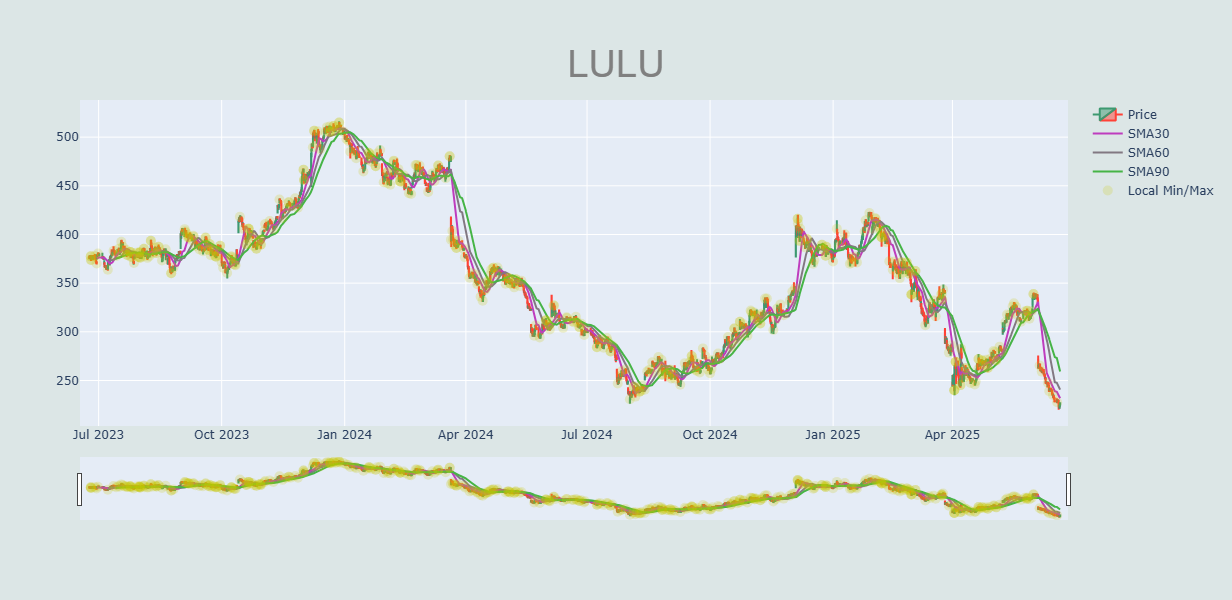

In [30]:
ticker = 'LULU'
df4 = df3[df3.ticker==ticker].copy()
minmax = Indicators.get_max_min(df4, smoothing, window)
fig = go.Figure(data=[go.Candlestick(x=df4['date'],
                open=df4['open'],
                high=df4['high'],
                low=df4['low'],
                close=df4['close'],
                name='Price')])
for n in SMAs:
        rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
        fig.add_trace(go.Scatter(x=df4['date'],
                y=df4['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax['date'],
                y=minmax['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.2)
                        ))
 
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
            ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

In [17]:
downpercent = len(df3[(df3[smacol1]==1)&(df3[smacol2] < 0)])/len(df3[df3[smacol1]==1])
avginc = df3[df3[smacol1]==1][smacol2].mean()
medinc = df3[df3[smacol1]==1][smacol2].median()
maxinc = df3[df3[smacol1]==1][smacol2].max()
print('Percent of Unsuccsessful observations is: {}'.format(format(downpercent,".2%")))
print('Average Increase/Decrease is: {}'.format(format(avginc,".2%")))
print('Median Increase/Decrease is: {}'.format(format(medinc,".2%")))
print('Maximum Increase/Decrease is: {}'.format(format(maxinc,".2%")))
df3[df3[smacol1]==1].groupby(['ticker'])[smacol2].describe().reset_index()

Percent of Unsuccsessful observations is: 11.62%
Average Increase/Decrease is: 5.93%
Median Increase/Decrease is: 4.48%
Maximum Increase/Decrease is: 48.64%


,ticker,count,mean,std,min,25%,50%,75%,max
0,ABNB,4.000,0.057,0.009,0.047,0.051,0.058,0.064,0.065
1,ADBE,7.000,0.056,0.010,0.041,0.050,0.056,0.065,0.066
2,ADM,16.000,0.050,0.028,-0.026,0.045,0.054,0.067,0.084
3,ALB,12.000,0.088,0.034,0.004,0.080,0.086,0.101,0.138
4,ALGN,22.000,0.059,0.024,0.009,0.046,0.055,0.077,0.100
...,...,...,...,...,...,...,...,...,...
141,WDC,2.000,0.124,0.062,0.080,0.102,0.124,0.146,0.168
142,WST,7.000,0.064,0.014,0.051,0.054,0.059,0.070,0.089
143,XEL,4.000,0.071,0.004,0.065,0.070,0.071,0.072,0.074
144,XYL,1.000,0.040,NaN,0.040,0.040,0.040,0.040,0.040


In [103]:
df3[df3[smacol1]==1][smacol2].describe()

count    1888.000000
mean        0.065195
std         0.073294
min        -0.128767
25%         0.015485
50%         0.047740
75%         0.093585
max         0.486355
Name: SMA30_future, dtype: float64